In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import scipy.stats

In [2]:
from network_tools import visualize_dag
from simulation_tools import pert_sample

## Christmas Market Project
Empirical project data proposed in the book Vanhoucke, M., 2023, "The illusion of control: Project data, computer algorithms and human intuition for project management and control", Springer

In [15]:
# Load the project data
df=pd.read_csv("./dataset/C2018-13-dataset.csv",sep=";")
df.head(1)

,ID,Name,WBS,Predecessors,Successors,Total Cost,Duration,Description,Optimistic,Most Probable,...,PAC,PRC,Remaining Duration,Actual Cost,Remaining Cost,Percentage Completed,Tracking,Earned Value (EV),Planned Value (PV),ad
0,1,START,1.1,NaN,FS2,0.0,0,standard - no risk,99.0,100.0,...,0.0,0.0,0,0.0,0.0,1.0,Finished,0.0,0.0,0.0


In [16]:
df.columns

Index(['ID', 'Name', 'WBS', 'Predecessors', 'Successors', 'Total Cost',
       'Duration', 'Description', 'Optimistic', 'Most Probable', 'Pessimistic',
       'd', 'o', 'm', 'p', 'Actual Duration', 'PAC', 'PRC',
       'Remaining Duration', 'Actual Cost', 'Remaining Cost',
       'Percentage Completed', 'Tracking', 'Earned Value (EV)',
       'Planned Value (PV)', 'ad'],
      dtype='object')

In [31]:
# Build the Activity on Node (AON) network
# The activity‐on‐node (AON) network is modeled as a Networkx directed acyclic 
Go=nx.DiGraph()
for i in df.index:
    mean_d=(df.loc[i,'o']+4*df.loc[i,'m']+df.loc[i,'p'])/6
    Go.add_node(df.loc[i,'ID'],
               planned_value = df.loc[i,'Total Cost'], # The planned value
               optimistic = df.loc[i,'o'], # The optimistic duration
               pessimistic = df.loc[i,'p'], # The pessimistic duration
               mostlikely = df.loc[i,'m'], # The most likely duration
               mean_duration=mean_d, # The mean duration
               cost_rate = (df.loc[i,'Total Cost'] / mean_d) if mean_d > 0 else 0) # The cost rate per day for the most likely duration
    if not pd.isna(df.loc[i,'Successors']):
        for s in df.loc[i,'Successors'].split(";"):
            Go.add_edge(df.loc[i,'ID'],int(s[2:]),type=s[:2])
print(f'AON graph with {Go.number_of_nodes()} nodes and {Go.number_of_edges()} edges')
print('Is G aperiodic?',nx.is_aperiodic(Go))  


AON graph with 33 nodes and 45 edges
Is G aperiodic? True


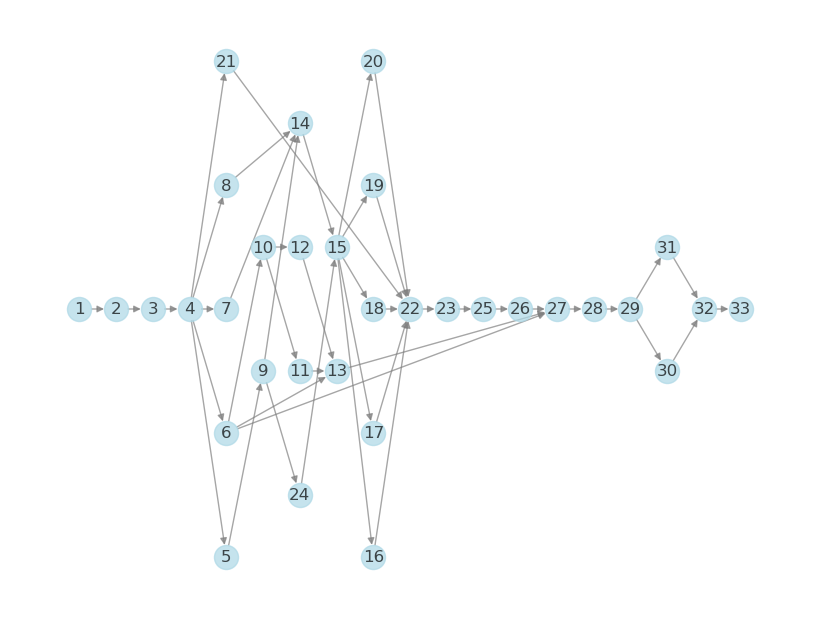

In [32]:
# Visualize the AON network
visualize_dag(Go)

In [33]:
# Project data at control time
df_control=df[['ID','Percentage Completed', 'Earned Value (EV)','Actual Cost', 'ad']]
df_control

,ID,Percentage Completed,Earned Value (EV),Actual Cost,ad
0,1,1.00,0.00,0.0,0.0
1,2,1.00,4000.00,5900.0,59.0
2,3,1.00,200.00,200.0,339.0
3,4,1.00,200.00,200.0,12.0
4,5,1.00,640.00,880.0,22.0
5,6,0.29,1388.43,1400.0,70.0
6,7,0.33,750.24,1400.0,70.0
7,8,0.37,825.26,1400.0,70.0
8,9,0.19,200.00,200.0,48.0
9,10,0.69,2305.88,4200.0,70.0


## Functions for simulation

In [36]:
# Draw random durations for the activities following a PERT distribution
def draw_random_durations(G,control=None):
    nx.set_node_attributes(G,0,'duration')
    if control is None:
        for n in list(G.nodes())[1:-1]: # Skip the start and end nodes
            G.nodes[n]['duration']=pert_sample(G.nodes[n]['optimistic'], G.nodes[n]['mostlikely'], G.nodes[n]['pessimistic'],size=1)[0]
    else:
        for i in control.index[1:-1]: # Skip the start and end nodes
            n=control.loc[i,'ID']
            
            if control.loc[i,'Percentage Completed']==1: # completed activity
                G.nodes[n]['duration']=control.loc[i,'ad'] # the duration is the actual duration
            
            elif control.loc[i,'Percentage Completed']>0 and control.loc[i,'Percentage Completed'] <1: # ongoing activity
                G.nodes[n]['duration']=pert_sample(G.nodes[n]['optimistic'], G.nodes[n]['mostlikely'], G.nodes[n]['pessimistic'],
                                                   elapsed_time=control.loc[i,'ad'],
                                                   complete_percent=control.loc[i,'Percentage Completed'],
                                                   size=1)[0]
            else: # not started activity
                G.nodes[n]['duration']=pert_sample(G.nodes[n]['optimistic'], G.nodes[n]['mostlikely'], G.nodes[n]['pessimistic'],size=1)[0]


In [55]:
def compute_actual_cost(G,control=None):
    nx.set_node_attributes(G,0,'cost')
    if control is None:
        for n in list(G.nodes())[1:-1]: # Skip the start and end nodes
            G.nodes[n]['cost']=G.nodes[n]['cost_rate']*G.nodes[n]['duration']
    else:
        for i in control.index[1:-1]: # Skip the start and end nodes
            n=control.loc[i,'ID']
            
            if control.loc[i,'Percentage Completed']==1: # completed activity
                G.nodes[n]['cost']=control.loc[i,'Actual Cost']
            
            elif control.loc[i,'Percentage Completed']>0 and control.loc[i,'Percentage Completed'] <1: # ongoing activity
                G.nodes[n]['cost_rate']=control.loc[i,'Actual Cost']/control.loc[i,'ad'] # Update the cost rate using the information at control time
                G.nodes[n]['cost']=G.nodes[n]['cost_rate']*G.nodes[n]['duration']
            
            else: # not started activity
                G.nodes[n]['cost']=G.nodes[n]['cost_rate']*G.nodes[n]['duration']

In [61]:
# Compute the start time of activities based on the dependencies
def compute_times(G,time='duration'):
    # time: duration or meanduration
    start_time={n:0 for n in G.nodes()} # initialize the start time dictionary
    for n in nx.topological_sort(G): # follow a list of nodes in topologically sorted order
        end=start_time[n] + G.nodes[n][time] # end time
        for j in G.neighbors(n):
            if G.edges[n,j]['type']=='FS': # Finish to Start dependency
                start_time[j]=np.max([start_time[j],end])
            if G.edges[n,j]['type']=='SS': # Start to Start dependency
                start_time[j]=np.max([start_time[j],start_time[n]])
    return start_time


In [98]:
# Checking without data at control time
G=Go.copy()
draw_random_durations(G)
compute_actual_cost(G)
for n, data in G.nodes(data=True):
    print(f"Task {n} has a duration of {data['duration']}")

Task 1 has a duration of 0
Task 2 has a duration of 39.36219114903237
Task 3 has a duration of 261.0144333066523
Task 4 has a duration of 10.568929398895023
Task 5 has a duration of 17.61472525551219
Task 6 has a duration of 241.08628833928216
Task 7 has a duration of 128.56391689989692
Task 8 has a duration of 124.75912610388738
Task 21 has a duration of 55.77530985054911
Task 9 has a duration of 172.82450982689414
Task 10 has a duration of 62.03102883845793
Task 27 has a duration of 240.15612886814432
Task 13 has a duration of 220.45585831267337
Task 14 has a duration of 10.170952347085592
Task 24 has a duration of 61.104655366714056
Task 11 has a duration of 10.618376238483524
Task 12 has a duration of 37.28924983422884
Task 15 has a duration of 16.745181529016765
Task 16 has a duration of 25.92571507772303
Task 18 has a duration of 18.00921483564707
Task 17 has a duration of 18.613231027787705
Task 19 has a duration of 8.288562048751066
Task 20 has a duration of 9.272317156607617
T

In [99]:
G.nodes[21]['duration']

55.77530985054911

In [59]:
# Checking with data at control time
G=Go.copy()
draw_random_durations(G,df_control)
compute_actual_cost(G,df_control)
for n, data in G.nodes(data=True):
    print(f"Node {n} has a duration of {data['duration']}")

Node 1 has a duration of 0
Node 2 has a duration of 59.0
Node 3 has a duration of 339.0
Node 4 has a duration of 12.0
Node 5 has a duration of 22.0
Node 6 has a duration of 136.05960828931987
Node 7 has a duration of 203.1910283580898
Node 8 has a duration of 169.7088145064059
Node 21 has a duration of 79.51158746654593
Node 9 has a duration of 179.7078640666423
Node 10 has a duration of 84.33166715106236
Node 27 has a duration of 240.87085895230064
Node 13 has a duration of 258.7575201516712
Node 14 has a duration of 11.37375064834228
Node 24 has a duration of 62.19741864159677
Node 11 has a duration of 11.157920645114274
Node 12 has a duration of 44.97451254001011
Node 15 has a duration of 16.673310520313905
Node 16 has a duration of 21.709192778285356
Node 18 has a duration of 15.777287380550295
Node 17 has a duration of 16.990394333597017
Node 19 has a duration of 8.516915135611027
Node 20 has a duration of 9.195839557193997
Node 22 has a duration of 17.790240745217844
Node 23 has 

In [60]:
G.nodes[21]['duration']

79.51158746654593

## Monte Carlo simulation

In [102]:
# Monte-Carlo simulation of the project
def simulation(G,experiment,control=None,Nruns=10000,echo=False):
    sim_list=list() # list of dictionaries with runs
    if echo: print('Starting simulation...')
    for m in range(Nruns):
        # Draw durations
        draw_random_durations(G,control)
        # Compute estimated cost
        compute_actual_cost(G,control)
        # Save run
        sim={'duration'+str(i):G.nodes[i]['duration'] for i in G.nodes()}
        sim.update({'cost'+str(i):G.nodes[i]['cost'] for i in G.nodes()})
        #sim.update({'planned_value'+str(i):G.nodes[i]['planned_value'] for i in G.nodes()})
        sim.update({'total_cost':np.sum([G.nodes[i]['cost'] for i in G.nodes()])})
        sim.update({'total_planned_value':np.sum([G.nodes[i]['planned_value'] for i in G.nodes()])})
        sim.update({'baseline_duration':np.max([t for t in compute_times(G,time='mean_duration').values()])})
        sim.update({'actual_duration':np.max([t for t in compute_times(G,time='duration').values()])})
        sim_list.append(sim)
        if echo: print(m)
    if echo: print('... end simulation')
    pd.DataFrame.from_dict(sim_list).to_csv('./data/simulation_christmas_market_' + experiment+ '.csv')

In [66]:
import time

In [120]:
start_time = time.time()
N=1000
simulation(Go.copy(),experiment='ev0',control=None,Nruns=N)
print(f"Monte Carlo Simulation took {time.time() - start_time} seconds to run {N} samples")

Monte Carlo Simulation took 3.987488031387329 seconds to run 1000 samples


In [121]:
start_time = time.time()
N=1000
simulation(Go.copy(),experiment='ev25',control=df_control,Nruns=N)
print(f"Monte Carlo Simulation took {time.time() - start_time} seconds to run {N} samples")

Monte Carlo Simulation took 7.142277002334595 seconds to run 1000 samples


In [69]:
import seaborn as sns
from matplotlib import pyplot as plt

In [70]:
sns.set_theme() # Set the default seaborn theme for matplotlib

###  Simulations from EV=0 (start of the project)

In [122]:
# Simulations from EV=0
df_sim=pd.read_csv('./data/simulation_christmas_market_ev0.csv')

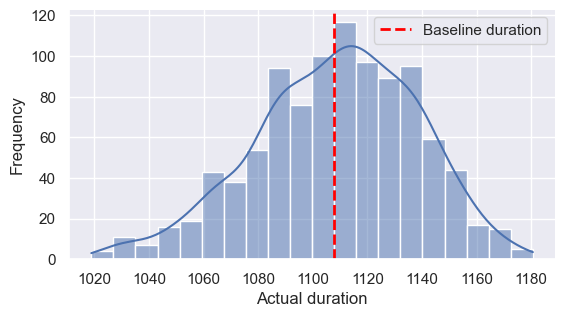

In [123]:
# Histogram of actual durations
g=sns.displot(df_sim['actual_duration'],kde=True)
plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
plt.legend()
g.set_axis_labels('Actual duration','Frequency')
g.figure.set_size_inches(6,3)

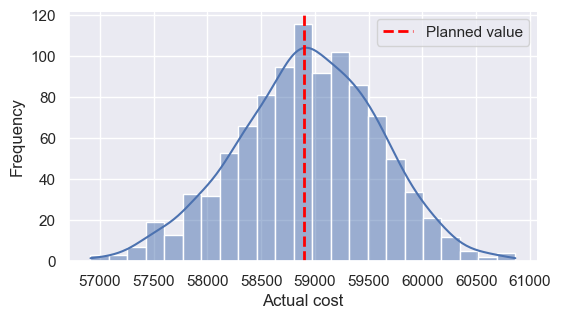

In [124]:
# Histogram of actual costs
g=sns.displot(df_sim['total_cost'],kde=True)
plt.axvline(x=df_sim.loc[0,'total_planned_value'], color='red', linestyle='--', linewidth=2,label='Planned value')
plt.legend()
g.set_axis_labels('Actual cost','Frequency')
g.figure.set_size_inches(6,3)

### Simulations from EV=25%

In [125]:
df_sim=pd.read_csv('./data/simulation_christmas_market_ev25.csv',index_col=0)

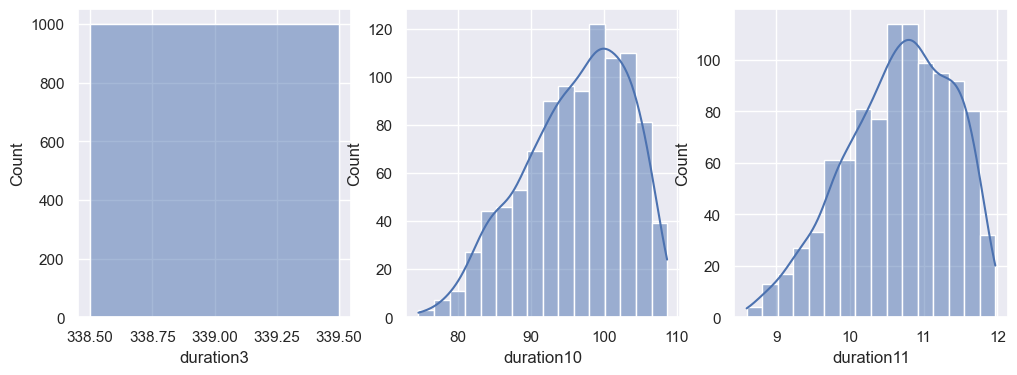

In [126]:
# Check the distribution of durations for some activities: finished, ongoing, not started at the control time
plt.figure(figsize=(12,4))
for i,n in enumerate([3,10,11]):
    plt.subplot(1,3,i+1)
    sns.histplot(df_sim['duration'+str(n)],kde=True)


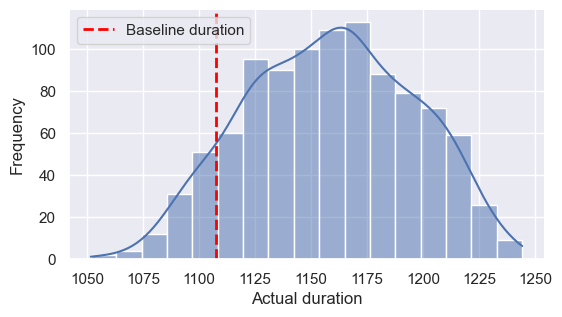

In [127]:
# Histogram of actual durations
g=sns.displot(df_sim['actual_duration'],kde=True)
plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
plt.legend()
g.set_axis_labels('Actual duration','Frequency')
g.figure.set_size_inches(6,3)

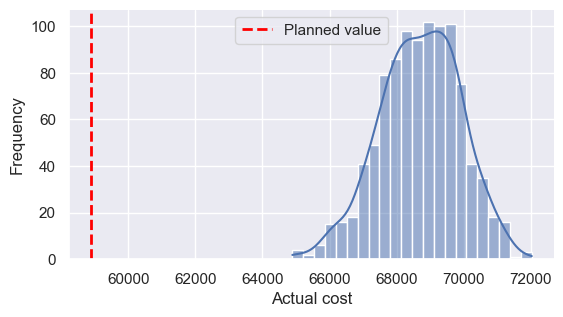

In [128]:
# Histogram of actual costs
g=sns.displot(df_sim['total_cost'],kde=True)
plt.axvline(x=df_sim.loc[0,'total_planned_value'], color='red', linestyle='--', linewidth=2,label='Planned value')
plt.legend()
g.set_axis_labels('Actual cost','Frequency')
g.figure.set_size_inches(6,3)

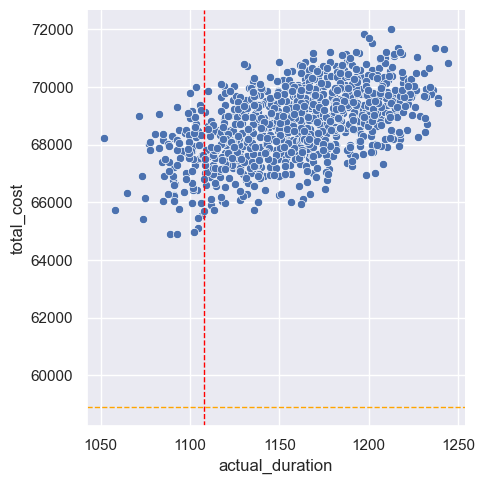

In [129]:
# Scatter plot of actual duration vs actual cost
sns.relplot(df_sim, x="actual_duration", y="total_cost")
plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=1,label='Baseline duration')
plt.axhline(y=df_sim.loc[0,'total_planned_value'], color='orange', linestyle='--', linewidth=1,label='Planned value')
g.set_axis_labels('Actual duration','Actual cost')
g.figure.set_size_inches(10,5)